# CQT Fakeprint: Real vs Theoretical Speed up / Pitch Shift

Compares pipeline CQT fakeprints:
- **Speed up** (vinyl-style, like `sox file.mp3 out.wav speed 1.02`): real = time-domain speed on audio; artificial = shift CQT in frequency.
- **Pitch shift**: real = torchaudio PitchShift on audio; artificial = shift CQT in frequency (same logic).

In [2]:
%cd ../..
!ls

/Users/thomas/projects/robust-deepfake-detector
README.md        deezer           requirements.txt src
data             outputs          scripts


In [ ]:
import os
import sys
import numpy as np
import torch
import torchaudio
import soxr
import matplotlib.pyplot as plt
import scipy.interpolate as interp

from nnAudio.features import CQT
from src.models.utils import get_spectrum, get_freqs, get_fakeprints

## Params (pipeline defaults)

In [4]:
N_FFT = 16384
SR = 48000
BINS_PER_OCTAVE = 96
FREQ_RANGE = [200, 6000]
F_MIN = 32.7
DB_RANGE = [-80, 5]

# Speed up (vinyl-style, like sox file.mp3 out.wav speed 1.02): same SR, shorter duration, pitch × factor
SPEED_FACTOR = 1.1
# Pitch shift: semitones (e.g. +2)
PITCH_SEMITONES = 2.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Helpers: CQT transform + fakeprint from waveform

In [5]:
def make_cqt_transform(sr, n_fft=N_FFT, f_min=F_MIN, bins_per_octave=BINS_PER_OCTAVE):
    hop_length = n_fft // 2
    nyquist = sr / 2
    n_octaves = np.log2(nyquist / f_min) - 0.1
    nbins = int(n_octaves * bins_per_octave)
    return CQT(
        sr=sr,
        hop_length=hop_length,
        fmin=f_min,
        n_bins=nbins,
        bins_per_octave=bins_per_octave,
        output_format="Magnitude",
        verbose=False,
    ).to(device)


def cqt_fakeprint_from_waveform(waveform, sr, cqt_transform, freqs, mask, db_range=DB_RANGE):
    """CQT -> dB -> mean(time) -> crop -> get_fakeprints (pipeline)."""
    waveform = waveform.mean(dim=0, keepdim=True).to(device)
    spec = get_spectrum(cqt_transform, waveform)
    spec = spec.mean(dim=-1).squeeze(0)
    spec_crop = spec[mask]
    return get_fakeprints(spec_crop, freqs, db_range=db_range)


def speed_up_waveform(waveform, speed):
    """Like SoX 'speed 1.02': shorter duration, pitch × speed. Same SR. waveform: (C, T)."""
    w = waveform.cpu().numpy()
    if w.ndim == 1:
        w = w[None, :]
    C, N = w.shape
    new_len = int(N / speed)
    indices_new = np.arange(new_len, dtype=np.float64) * speed
    out = np.stack([np.interp(indices_new, np.arange(N), w[c]) for c in range(C)])
    return torch.from_numpy(out).to(waveform.dtype).to(waveform.device)

## Load audio

In [22]:
import random
from tabnanny import verbose

audio_path = os.path.join("data/ai/0a0c8704df901b01437f850951dae249b60eb142a026a77d783c2688209e52ce.mp3")

# Get the duration of the audio
info = torchaudio.info(audio_path)
total_secs = info.num_frames / info.sample_rate
segment_secs = 30

if total_secs <= segment_secs:
    # Audio is shorter than 30 seconds, load entire file
    offset = 0
    num_frames = -1
else:
    # Pick a random start for a 30 second window
    max_offset_sec = total_secs - segment_secs
    offset_sec = random.uniform(0, max_offset_sec)
    offset = int(offset_sec * info.sample_rate)
    num_frames = int(segment_secs * info.sample_rate)

waveform, sr = torchaudio.load(audio_path, frame_offset=offset, num_frames=num_frames, channels_first=True)
if sr != SR:
    waveform = torch.from_numpy(soxr.resample(waveform.T.numpy(), sr, SR)).T.to(waveform.dtype)
    sr = SR
waveform = waveform.to(device)
print(f"Shape {waveform.shape}, sr={sr}, offset={offset/sr:.2f}s, duration={waveform.shape[-1]/sr:.2f}s")

Shape torch.Size([2, 1440000]), sr=48000, offset=264.45s, duration=30.00s


## Reference CQT fakeprint (original SR)

In [23]:
cqt_ref = make_cqt_transform(SR)
freqs_ref, mask_ref = get_freqs(N_FFT, SR, transform="cqt", bins_per_octave=BINS_PER_OCTAVE, freq_range=FREQ_RANGE, f_min=F_MIN)
freqs_ref = freqs_ref.to(device)

# Reference CQT spectrum (dB, mean time) and fakeprint
with torch.no_grad():
    spec_ref = get_spectrum(cqt_ref, waveform.mean(dim=0, keepdim=True))
spec_ref = spec_ref.mean(dim=-1).squeeze(0)[mask_ref].cpu().numpy()
fp_ref = cqt_fakeprint_from_waveform(waveform, SR, cqt_ref, freqs_ref, mask_ref)
fp_ref = fp_ref.cpu().numpy()
freqs_ref_np = freqs_ref.cpu().numpy()
print(f"Reference: CQT shape {spec_ref.shape}, fakeprint length {len(fp_ref)}")

Reference: CQT shape (471,), fakeprint length 471


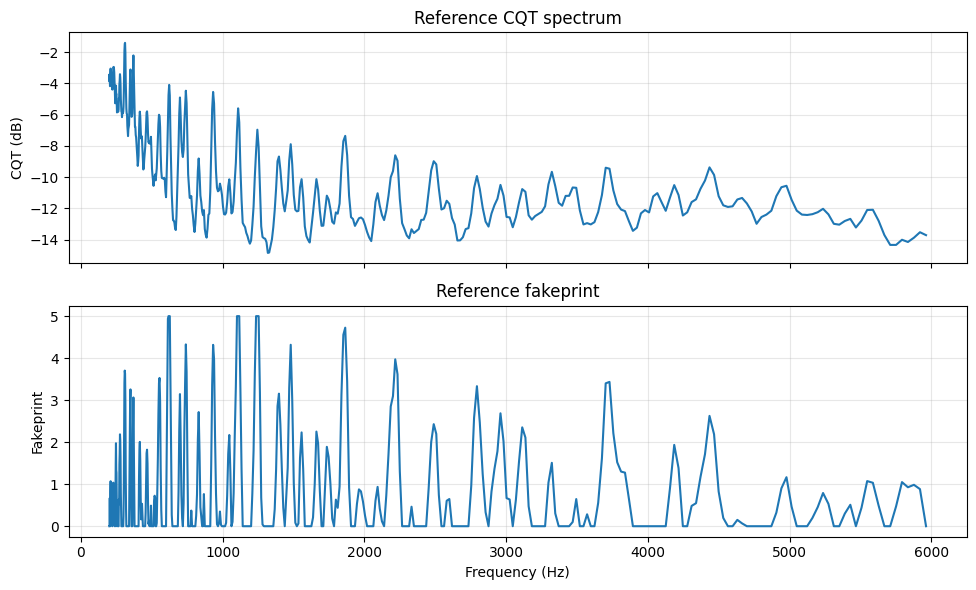

In [24]:
# Reference: CQT spectrum and fakeprint
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(freqs_ref_np, spec_ref, color="C0")
axes[0].set_ylabel("CQT (dB)")
axes[0].set_title("Reference CQT spectrum")
axes[0].grid(True, alpha=0.3)
axes[1].plot(freqs_ref_np, fp_ref, color="C0")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Fakeprint")
axes[1].set_title("Reference fakeprint")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 1. Speed up (vinyl-style): Real vs Artificial

Like `sox file.mp3 out.wav speed 1.02`: play faster → shorter duration, pitch × factor.

- **Real**: apply `speed_up_waveform(waveform, SPEED_FACTOR)` (time-domain resample), then CQT + fakeprint at same SR.
- **Artificial**: theoretical shift on CQT: content at f moves to f × speed, so value at f = ref spectrum at f / speed (interpolate).

In [25]:
# Real: speed up audio (vinyl-style), same SR -> CQT + fakeprint
wave_speed = speed_up_waveform(waveform, SPEED_FACTOR)
with torch.no_grad():
    spec_speed_real = get_spectrum(cqt_ref, wave_speed.mean(dim=0, keepdim=True)).mean(dim=-1).squeeze(0)[mask_ref].cpu().numpy()
fp_speed_real = cqt_fakeprint_from_waveform(wave_speed, SR, cqt_ref, freqs_ref, mask_ref)
fp_speed_real = fp_speed_real.cpu().numpy()

# Artificial: theoretical shift on CQT — value at f = ref(f/speed)
freqs_shifted = freqs_ref_np / SPEED_FACTOR
interp_ref = interp.interp1d(freqs_ref_np, spec_ref, kind="linear", bounds_error=False, fill_value=(spec_ref.min(), spec_ref.max()))
spec_speed_art = interp_ref(freqs_shifted)
spec_shifted = torch.from_numpy(spec_speed_art).float().to(device)
fp_speed_art = get_fakeprints(spec_shifted, freqs_ref, db_range=DB_RANGE).cpu().numpy()

print(f"Speed {SPEED_FACTOR}: ref duration {waveform.shape[-1]/SR:.2f}s -> sped {wave_speed.shape[-1]/SR:.2f}s")

Speed 1.1: ref duration 30.00s -> sped 27.27s


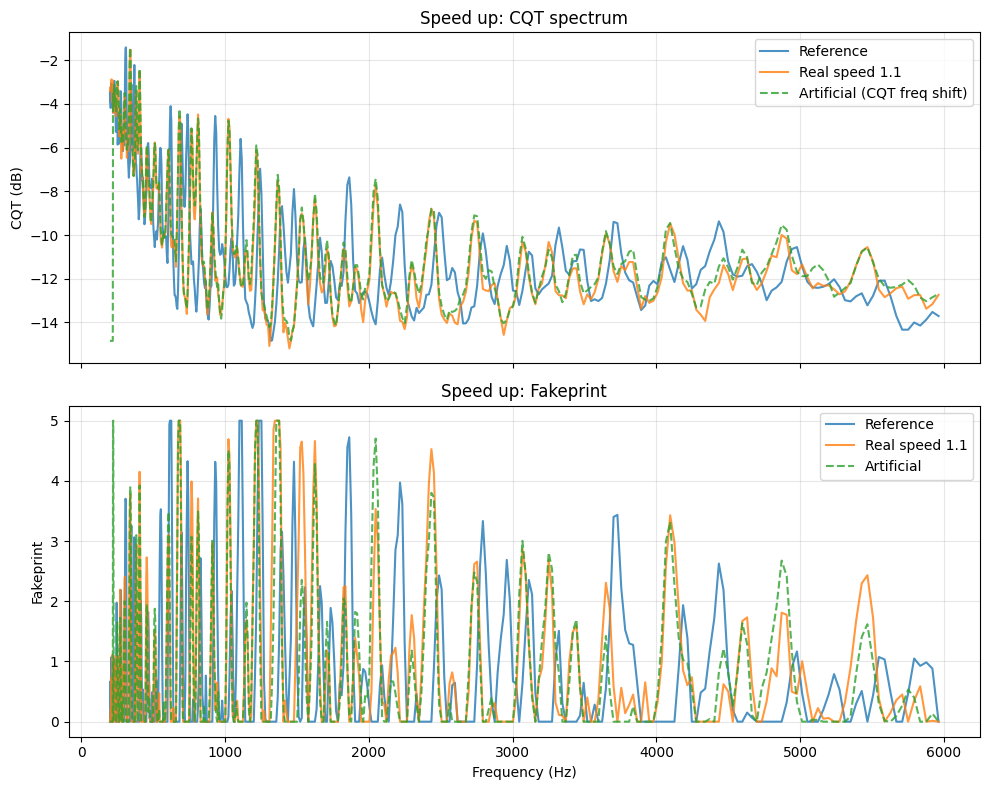

In [26]:
# Speed up: CQT and fakeprint comparison
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(freqs_ref_np, spec_ref, label="Reference", alpha=0.8)
axes[0].plot(freqs_ref_np, spec_speed_real, label=f"Real speed {SPEED_FACTOR}", alpha=0.8)
axes[0].plot(freqs_ref_np, spec_speed_art, label="Artificial (CQT freq shift)", alpha=0.8, linestyle="--")
axes[0].set_ylabel("CQT (dB)")
axes[0].set_title("Speed up: CQT spectrum")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs_ref_np, fp_ref, label="Reference", alpha=0.8)
axes[1].plot(freqs_ref_np, fp_speed_real, label=f"Real speed {SPEED_FACTOR}", alpha=0.8)
axes[1].plot(freqs_ref_np, fp_speed_art, label="Artificial", alpha=0.8, linestyle="--")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Fakeprint")
axes[1].set_title("Speed up: Fakeprint")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

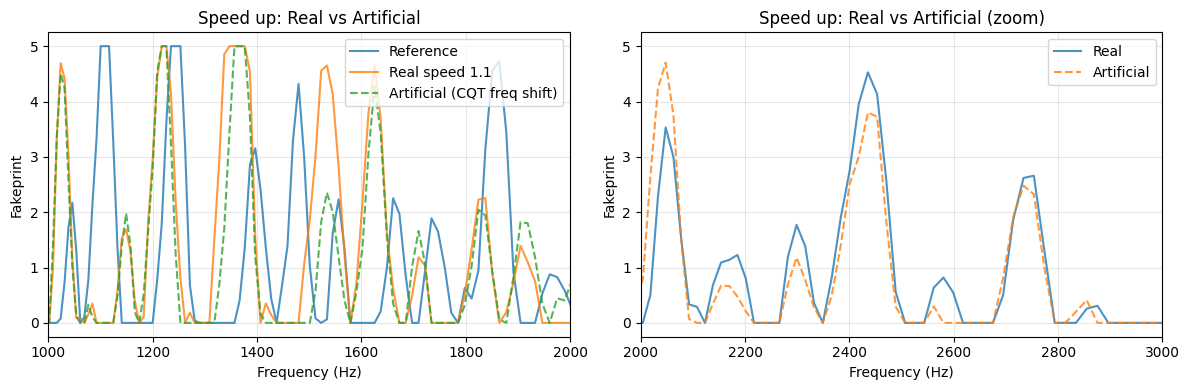

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.plot(freqs_ref_np, fp_ref, label="Reference", alpha=0.8)
ax.plot(freqs_ref_np, fp_speed_real, label=f"Real speed {SPEED_FACTOR}", alpha=0.8)
ax.plot(freqs_ref_np, fp_speed_art, label="Artificial (CQT freq shift)", alpha=0.8, linestyle="--")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Fakeprint")
ax.set_title("Speed up: Real vs Artificial")
ax.set_xlim(1000, 2000)
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(freqs_ref_np, fp_speed_real, label="Real", alpha=0.8)
ax.plot(freqs_ref_np, fp_speed_art, label="Artificial", alpha=0.8, linestyle="--")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Fakeprint")
ax.set_title("Speed up: Real vs Artificial (zoom)")
ax.set_xlim(2000, 3000)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Pitch shift: Real vs Artificial

- **Real**: pitch shift audio by `PITCH_SEMITONES` semitones, then CQT + fakeprint.
- **Artificial**: theoretical shift in frequency: content at f moves to f × 2^(n/12). So new spectrum at f_new = ref spectrum at f_new / 2^(n/12) (interpolate on CQT).

In [28]:
ratio = 2.0 ** (PITCH_SEMITONES / 12.0)

# Real: pitch shift on audio
pitch_shifter = torchaudio.transforms.PitchShift(sample_rate=SR, n_steps=PITCH_SEMITONES).to(device)
wave_ps = pitch_shifter(waveform)
with torch.no_grad():
    spec_ps_real = get_spectrum(cqt_ref, wave_ps.mean(dim=0, keepdim=True)).mean(dim=-1).squeeze(0)[mask_ref].cpu().numpy()
fp_ps_real = cqt_fakeprint_from_waveform(wave_ps, SR, cqt_ref, freqs_ref, mask_ref)
fp_ps_real = fp_ps_real.cpu().numpy()

# Artificial: shift CQT in freq: value at f_new = ref(f_new / ratio)
freqs_shifted = freqs_ref_np / ratio
interp_ref = interp.interp1d(freqs_ref_np, spec_ref, kind="linear", bounds_error=False, fill_value=(spec_ref.min(), spec_ref.max()))
spec_ps_art = interp_ref(freqs_shifted)
spec_shifted = torch.from_numpy(spec_ps_art).float().to(device)
fp_ps_art = get_fakeprints(spec_shifted, freqs_ref, db_range=DB_RANGE).cpu().numpy()

/Users/thomas/projects/robust-deepfake-detector/.venv/lib/python3.11/site-packages/torch/nn/modules/lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


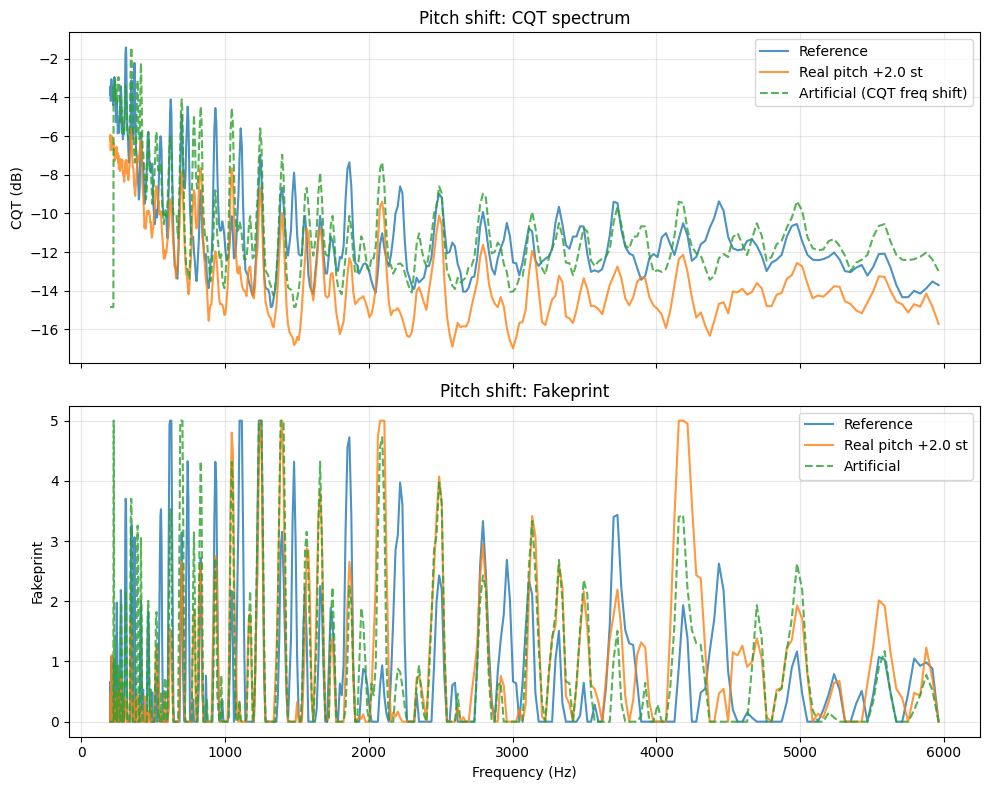

In [29]:
# Pitch shift: CQT and fakeprint comparison
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(freqs_ref_np, spec_ref, label="Reference", alpha=0.8)
axes[0].plot(freqs_ref_np, spec_ps_real, label=f"Real pitch {PITCH_SEMITONES:+.1f} st", alpha=0.8)
axes[0].plot(freqs_ref_np, spec_ps_art, label="Artificial (CQT freq shift)", alpha=0.8, linestyle="--")
axes[0].set_ylabel("CQT (dB)")
axes[0].set_title("Pitch shift: CQT spectrum")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs_ref_np, fp_ref, label="Reference", alpha=0.8)
axes[1].plot(freqs_ref_np, fp_ps_real, label=f"Real pitch {PITCH_SEMITONES:+.1f} st", alpha=0.8)
axes[1].plot(freqs_ref_np, fp_ps_art, label="Artificial", alpha=0.8, linestyle="--")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Fakeprint")
axes[1].set_title("Pitch shift: Fakeprint")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary: same axes (reference freq grid)

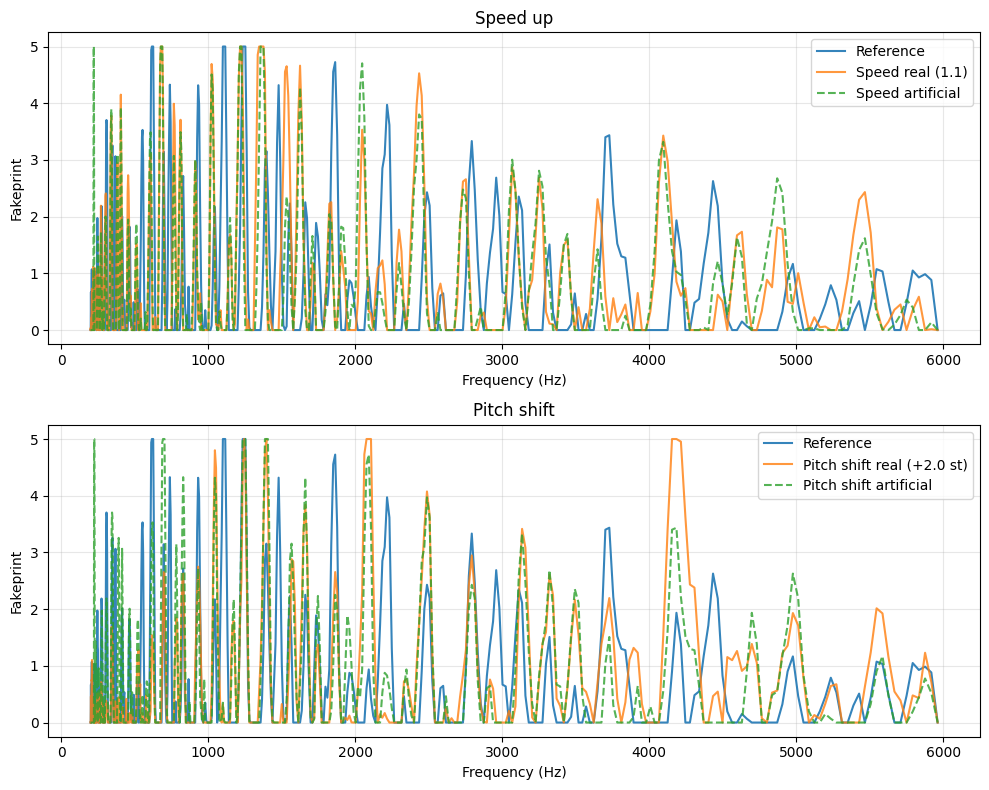

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
axes[0].plot(freqs_ref_np, fp_ref, label="Reference", alpha=0.9)
axes[0].plot(freqs_ref_np, fp_speed_real, label=f"Speed real ({SPEED_FACTOR})", alpha=0.8)
axes[0].plot(freqs_ref_np, fp_speed_art, label="Speed artificial", linestyle="--", alpha=0.8)
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Fakeprint")
axes[0].set_title("Speed up")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs_ref_np, fp_ref, label="Reference", alpha=0.9)
axes[1].plot(freqs_ref_np, fp_ps_real, label=f"Pitch shift real ({PITCH_SEMITONES:+.1f} st)", alpha=0.8)
axes[1].plot(freqs_ref_np, fp_ps_art, label="Pitch shift artificial", linestyle="--", alpha=0.8)
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Fakeprint")
axes[1].set_title("Pitch shift")
ax
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Interpolation vs Discrete Roll — which artificial shift to use for training?

In CQT, bins are log-spaced: `f_k = f_min * 2^(k / bins_per_octave)`.
A speed factor `s` shifts the spectrum by `alpha0 = log2(s) * bins_per_octave` bins.

Two approaches:
- **Interpolation**: `spec(f) = ref(f / s)` — continuous, accurate, but expensive (scipy interp)
- **Discrete roll**: `torch.roll(fakeprint, alpha0_int)` — fast, GPU-friendly, but rounds to integer bins

We compare both against the **real** speed-up for multiple speed factors in [0.75, 1.25].

In [31]:
def artificial_shift_interp(fakeprint_np, freqs_np, speed_factor, spec_ref_np, db_range=DB_RANGE):
    """Artificial shift via frequency interpolation on the CQT spectrum, then recompute fakeprint."""
    freqs_shifted = freqs_np / speed_factor
    interp_fn = interp.interp1d(
        freqs_np, spec_ref_np, kind="linear",
        bounds_error=False, fill_value=(spec_ref_np.min(), spec_ref_np.max())
    )
    spec_art = interp_fn(freqs_shifted)
    spec_t = torch.from_numpy(spec_art).float().to(device)
    freqs_t = torch.from_numpy(freqs_np).float().to(device)
    fp_art = get_fakeprints(spec_t, freqs_t, db_range=db_range).cpu().numpy()
    return fp_art


def artificial_shift_roll(fakeprint_np, speed_factor, bins_per_octave=BINS_PER_OCTAVE):
    """Artificial shift via discrete torch.roll on the fakeprint itself."""
    alpha0 = np.log2(speed_factor) * bins_per_octave
    alpha0_int = int(round(alpha0))
    fp_t = torch.from_numpy(fakeprint_np).float()
    fp_rolled = torch.roll(fp_t, shifts=alpha0_int, dims=0)
    # Zero-fill the wrapped-around region
    if alpha0_int > 0:
        fp_rolled[:alpha0_int] = 0.0
    elif alpha0_int < 0:
        fp_rolled[alpha0_int:] = 0.0
    return fp_rolled.numpy(), alpha0, alpha0_int


def mse(a, b):
    return np.mean((a - b) ** 2)

def corr(a, b):
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return 0.0
    return np.corrcoef(a, b)[0, 1]

### Single speed factor comparison (SPEED_FACTOR)

Speed 1.1 → alpha0 = 13.20 bins (rounded to 13)
  Interp vs Real:  MSE=0.372278  corr=0.8875
  Roll   vs Real:  MSE=0.271678  corr=0.9190
  Interp vs Roll:  MSE=0.185982  corr=0.9394


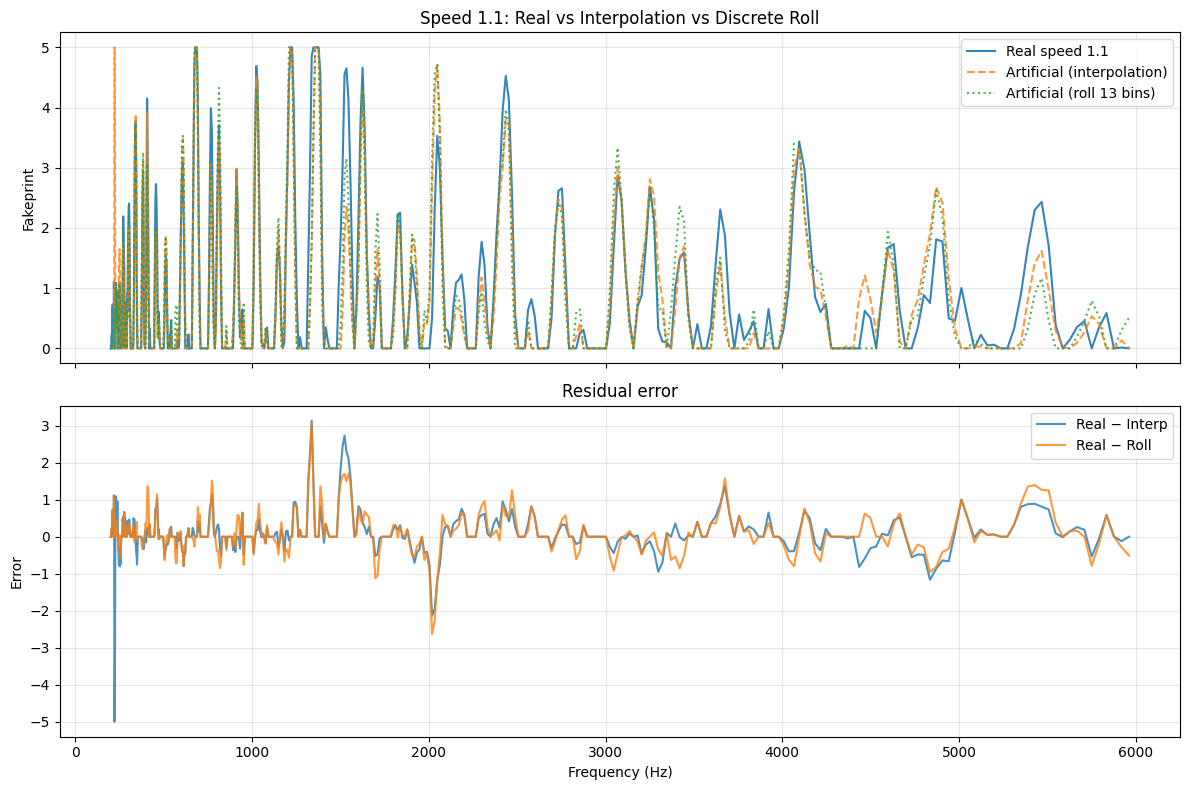

In [32]:
fp_interp = artificial_shift_interp(fp_ref, freqs_ref_np, SPEED_FACTOR, spec_ref)
fp_roll, alpha0_cont, alpha0_int = artificial_shift_roll(fp_ref, SPEED_FACTOR)

print(f"Speed {SPEED_FACTOR} → alpha0 = {alpha0_cont:.2f} bins (rounded to {alpha0_int})")
print(f"  Interp vs Real:  MSE={mse(fp_interp, fp_speed_real):.6f}  corr={corr(fp_interp, fp_speed_real):.4f}")
print(f"  Roll   vs Real:  MSE={mse(fp_roll, fp_speed_real):.6f}  corr={corr(fp_roll, fp_speed_real):.4f}")
print(f"  Interp vs Roll:  MSE={mse(fp_interp, fp_roll):.6f}  corr={corr(fp_interp, fp_roll):.4f}")

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(freqs_ref_np, fp_speed_real, label=f"Real speed {SPEED_FACTOR}", alpha=0.9)
axes[0].plot(freqs_ref_np, fp_interp, label="Artificial (interpolation)", alpha=0.8, linestyle="--")
axes[0].plot(freqs_ref_np, fp_roll, label=f"Artificial (roll {alpha0_int} bins)", alpha=0.8, linestyle=":")
axes[0].set_ylabel("Fakeprint")
axes[0].set_title(f"Speed {SPEED_FACTOR}: Real vs Interpolation vs Discrete Roll")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs_ref_np, fp_speed_real - fp_interp, label="Real − Interp", alpha=0.8)
axes[1].plot(freqs_ref_np, fp_speed_real - fp_roll, label="Real − Roll", alpha=0.8)
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Error")
axes[1].set_title("Residual error")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Sweep over speed factors [0.75, 1.25] — error curves

In [33]:
speed_factors = np.linspace(0.75, 1.25, 21)
speed_factors = speed_factors[speed_factors != 1.0]  # skip identity

results = []
for sf in speed_factors:
    # Real speed-up
    wave_sf = speed_up_waveform(waveform, sf)
    fp_real_sf = cqt_fakeprint_from_waveform(wave_sf, SR, cqt_ref, freqs_ref, mask_ref).cpu().numpy()
    
    # Interpolation-based artificial
    fp_interp_sf = artificial_shift_interp(fp_ref, freqs_ref_np, sf, spec_ref)
    
    # Discrete roll-based artificial
    fp_roll_sf, a0_cont, a0_int = artificial_shift_roll(fp_ref, sf)
    
    results.append({
        "speed": sf,
        "alpha0_cont": a0_cont,
        "alpha0_int": a0_int,
        "mse_interp": mse(fp_interp_sf, fp_real_sf),
        "mse_roll": mse(fp_roll_sf, fp_real_sf),
        "corr_interp": corr(fp_interp_sf, fp_real_sf),
        "corr_roll": corr(fp_roll_sf, fp_real_sf),
    })

import pandas as pd
df = pd.DataFrame(results)
print(df.to_string(index=False, float_format="%.4f"))

 speed  alpha0_cont  alpha0_int  mse_interp  mse_roll  corr_interp  corr_roll
0.7500     -39.8436         -40      0.1785    0.2101       0.9474     0.9360
0.7750     -35.3023         -35      0.1565    0.2236       0.9576     0.9330
0.8000     -30.9051         -31      0.1939    0.2044       0.9439     0.9392
0.8250     -26.6433         -27      0.1292    0.2695       0.9616     0.9134
0.8500     -22.5087         -23      0.1607    0.3170       0.9541     0.8999
0.8750     -18.4939         -18      0.1910    0.3565       0.9439     0.8853
0.9000     -14.5923         -15      0.1946    0.2963       0.9474     0.9092
0.9250     -10.7976         -11      0.3734    0.1792       0.8848     0.9455
0.9500      -7.1041          -7      0.5374    0.2344       0.8413     0.9298
0.9750      -3.5065          -4      0.3190    0.3466       0.9068     0.8948
1.0250       3.4199           3      0.3049    0.3289       0.9013     0.8916
1.0500       6.7574           7      0.2790    0.2666       0.91

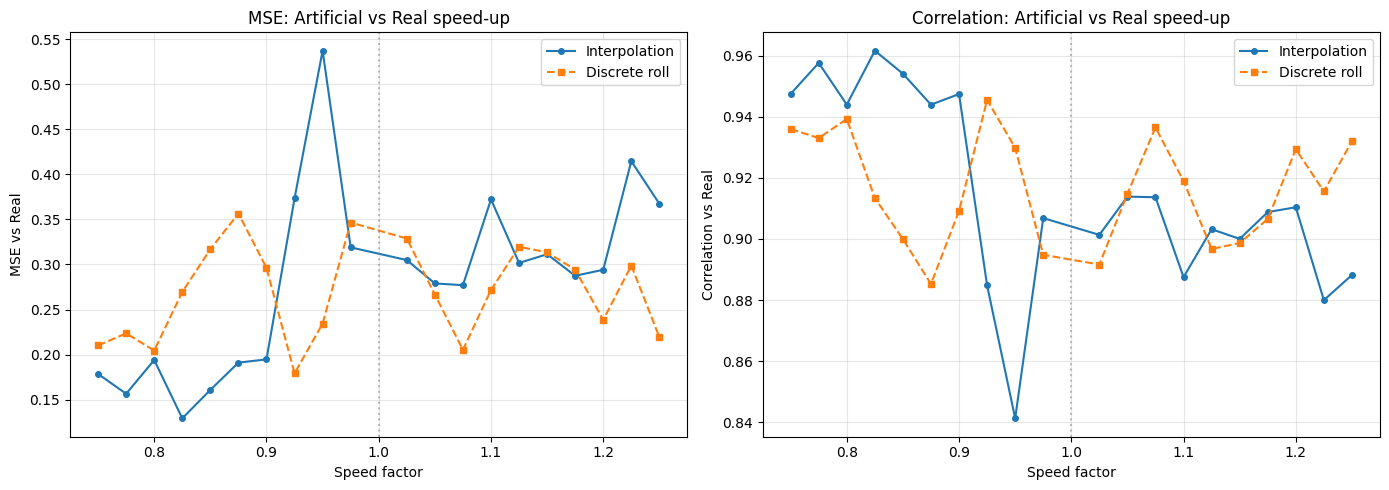

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df["speed"], df["mse_interp"], "o-", label="Interpolation", markersize=4)
axes[0].plot(df["speed"], df["mse_roll"], "s--", label="Discrete roll", markersize=4)
axes[0].set_xlabel("Speed factor")
axes[0].set_ylabel("MSE vs Real")
axes[0].set_title("MSE: Artificial vs Real speed-up")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axvline(1.0, color="gray", linestyle=":", alpha=0.5)

axes[1].plot(df["speed"], df["corr_interp"], "o-", label="Interpolation", markersize=4)
axes[1].plot(df["speed"], df["corr_roll"], "s--", label="Discrete roll", markersize=4)
axes[1].set_xlabel("Speed factor")
axes[1].set_ylabel("Correlation vs Real")
axes[1].set_title("Correlation: Artificial vs Real speed-up")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axvline(1.0, color="gray", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

### Visual comparison at several key speed factors

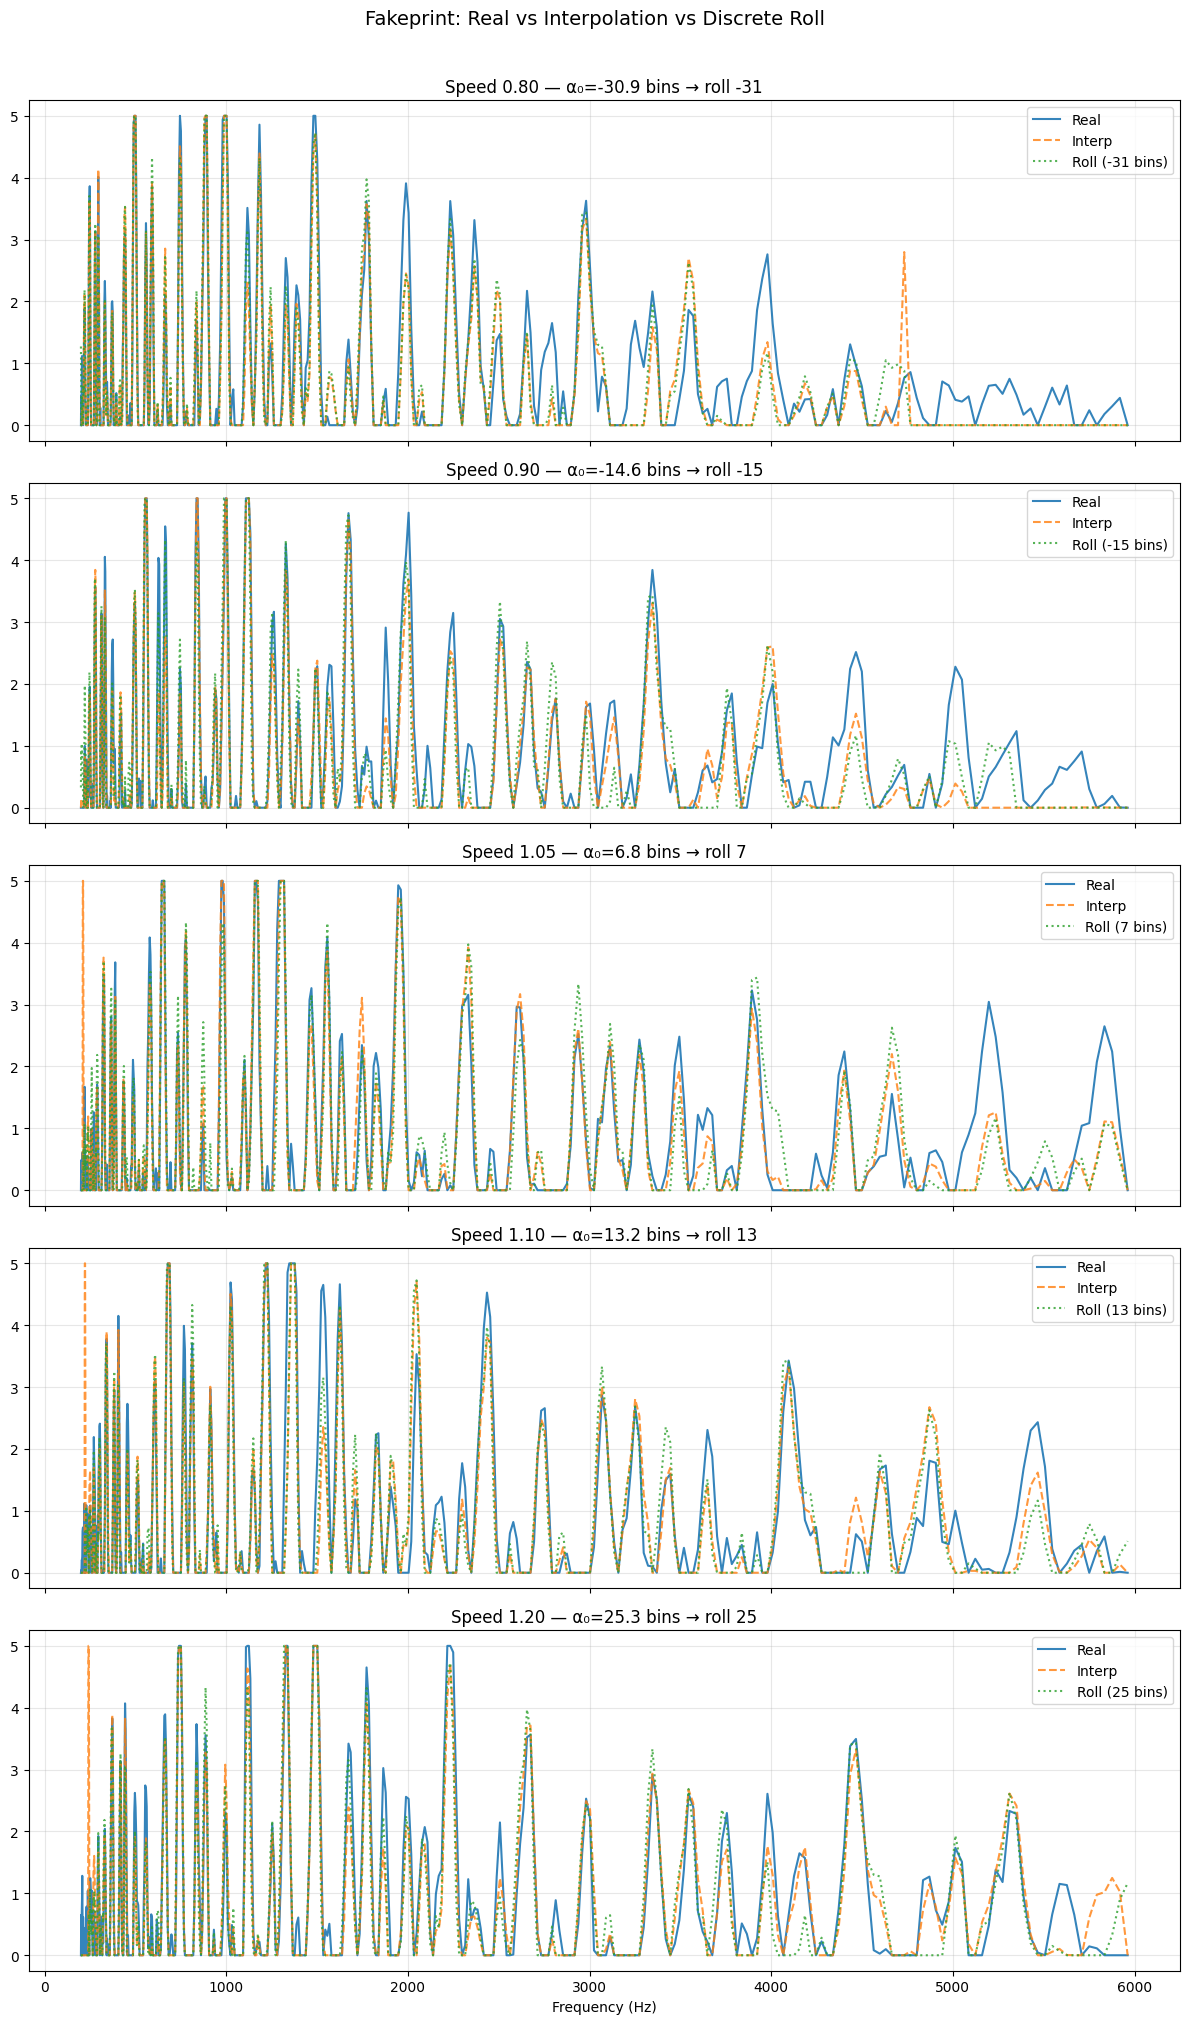

In [35]:
test_speeds = [0.80, 0.90, 1.05, 1.10, 1.20]
fig, axes = plt.subplots(len(test_speeds), 1, figsize=(12, 4 * len(test_speeds)), sharex=True)

for ax, sf in zip(axes, test_speeds):
    wave_sf = speed_up_waveform(waveform, sf)
    fp_real_sf = cqt_fakeprint_from_waveform(wave_sf, SR, cqt_ref, freqs_ref, mask_ref).cpu().numpy()
    fp_interp_sf = artificial_shift_interp(fp_ref, freqs_ref_np, sf, spec_ref)
    fp_roll_sf, a0c, a0i = artificial_shift_roll(fp_ref, sf)
    
    ax.plot(freqs_ref_np, fp_real_sf, label="Real", alpha=0.9)
    ax.plot(freqs_ref_np, fp_interp_sf, label="Interp", alpha=0.8, linestyle="--")
    ax.plot(freqs_ref_np, fp_roll_sf, label=f"Roll ({a0i} bins)", alpha=0.8, linestyle=":")
    ax.set_title(f"Speed {sf:.2f} — α₀={a0c:.1f} bins → roll {a0i}")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Frequency (Hz)")
fig.suptitle("Fakeprint: Real vs Interpolation vs Discrete Roll", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Alpha0 distribution preview — symmetric range + truncated normal

For a **symmetric** alpha0 range, the speed range must be `[1/s, s]` (so that `log2(1/s) = -log2(s)`).
With `s = 1.25`: speed range `[0.8, 1.25]` → alpha0 range `[-31, +31]` bins.

**Truncated normal** (rejection sampling) instead of clipping avoids probability stacking at edges.

Symmetric speed range: [0.8000, 1.2500]
Alpha0 range: [-30.91, 30.91] → integer [-30, 30]


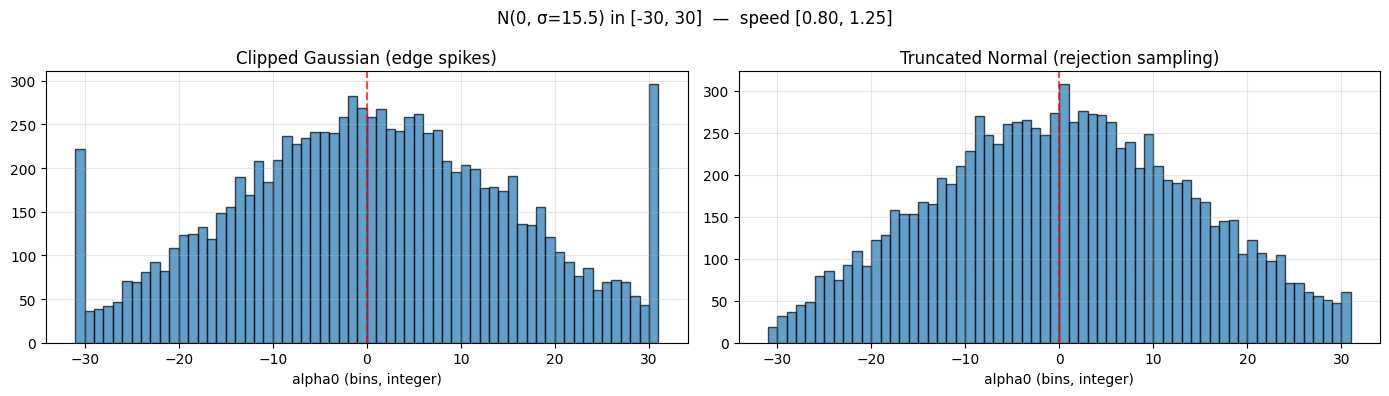

In [44]:
def symmetric_speed_range(s_max):
    """Return [1/s_max, s_max] so log2 range is symmetric around 0."""
    return [1.0 / s_max, s_max]

def sample_truncated_normal(mean, std, low, high, n):
    """Rejection sampling: draw from N(mean, std) but only keep samples in [low, high]."""
    samples = np.empty(n)
    filled = 0
    while filled < n:
        batch = np.random.normal(mean, std, size=n - filled)
        valid = batch[(batch >= low) & (batch <= high)]
        samples[filled:filled + len(valid)] = valid
        filled += len(valid)
    return samples

# Symmetric speed range
S_MAX = 1.25
speed_min, speed_max = symmetric_speed_range(S_MAX)
alpha0_min = np.log2(speed_min) * BINS_PER_OCTAVE
alpha0_max = np.log2(speed_max) * BINS_PER_OCTAVE
alpha0_min_int = int(np.ceil(alpha0_min))
alpha0_max_int = int(np.floor(alpha0_max))

print(f"Symmetric speed range: [{speed_min:.4f}, {speed_max:.4f}]")
print(f"Alpha0 range: [{alpha0_min:.2f}, {alpha0_max:.2f}] → integer [{alpha0_min_int}, {alpha0_max_int}]")

alpha0_std = (alpha0_max - alpha0_min) / 4

# Compare: clipped vs truncated
N_SAMPLES = 10000
clipped = np.clip(np.random.normal(0, alpha0_std, N_SAMPLES), alpha0_min, alpha0_max)
truncated = sample_truncated_normal(0, alpha0_std, alpha0_min, alpha0_max, N_SAMPLES)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, data, title in [
    (axes[0], clipped, f"Clipped Gaussian (edge spikes)"),
    (axes[1], truncated, f"Truncated Normal (rejection sampling)"),
]:
    data_int = np.round(data).astype(int)
    ax.hist(data_int, bins=range(alpha0_min_int - 1, alpha0_max_int + 2), edgecolor="black", alpha=0.7)
    ax.axvline(0, color="red", linestyle="--", alpha=0.7)
    ax.set_xlabel("alpha0 (bins, integer)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
plt.suptitle(f"N(0, σ={alpha0_std:.1f}) in [{alpha0_min_int}, {alpha0_max_int}]  —  speed [{speed_min:.2f}, {speed_max:.2f}]", fontsize=12)
plt.tight_layout()
plt.show()